* PHASE ONE - DATA SCIENCE PROJECT


In [2]:
pip install kagglehub


Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khsamaha/aviation-accident-database-synopses")

print("Path to dataset files:", path)

c:\Users\USER\anaconda3\envs\DataScience_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\khsamaha\aviation-accident-database-synopses\versions\15


In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv(r'C:\Users\USER\Desktop\Moringa\Phase1\PROJECT_PHASE1\Data\AviationData.csv', encoding="Windows-1252", low_memory=False, sep=',', header=0)
df.head() ## Display first five rows to understand data structure

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,24/10/1948,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,19/07/1962,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19/09/1996
2,20061025X01555,Accident,NYC07LA005,30/08/1974,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26/02/2007
3,20001218X45448,Accident,LAX96LA321,19/06/1977,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12/09/2000
4,20041105X01764,Accident,CHI79FA064,02/08/1979,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16/04/1980


In [6]:
#Displaying information about the data

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

In [7]:
#Interpretation: The data has 88889 records. It is made up of 31 columns and the dataframe has consumed 21MB storage. 

In [8]:
# Getting the column names
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [9]:
# This is important so that we check for whitespace from the column using lambda to effect on all 
df.rename(columns=lambda x:x.strip(), inplace=True)

DATA CLEANING

In [10]:
# Check for duplicate rows
duplicate_rows = df.duplicated().any()
duplicate_rows

# The result is that there is no duplicate rows

np.False_

In [11]:
#checking for duplicates in unique identifier
df.duplicated(subset='Event.Id').any()

np.True_

In [12]:
#checking for the number of duplicates in unique identifier
df.duplicated(subset='Event.Id').sum()


np.int64(4421)

In [13]:
df.duplicated(subset='Event.Id').sum() / len(df), 3

(np.float64(0.049736187829765216), 3)

In [14]:
#To get the index of rows with duplicated event IDs

duplicated_indices = df[df['Event.Id'].duplicated(keep=False)]
duplicated_indices
#Filter this


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
117,20020917X01908,Accident,DCA82AA012B,19/01/1982,"ROCKPORT, TX",United States,NaN,NaN,RKP,ARANSAS COUNTY AIRPORT,...,Personal,NaN,3.0,0.0,0.0,0.0,IMC,Approach,Probable Cause,19/01/1983
118,20020917X01908,Accident,DCA82AA012A,19/01/1982,"ROCKPORT, TX",United States,NaN,NaN,RKP,ARANSAS COUNTY AIRPORT,...,Executive/corporate,NaN,3.0,0.0,0.0,0.0,IMC,Approach,Probable Cause,19/01/1983
153,20020917X02259,Accident,LAX82FA049A,23/01/1982,"VICTORVILLE, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,4.0,0.0,VMC,Unknown,Probable Cause,23/01/1983
158,20020917X02400,Accident,MIA82FA038B,23/01/1982,"NEWPORT RICHEY, FL",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,0.0,0.0,3.0,VMC,Cruise,Probable Cause,23/01/1983
159,20020917X02400,Accident,MIA82FA038A,23/01/1982,"NEWPORT RICHEY, FL",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,0.0,0.0,3.0,VMC,Approach,Probable Cause,23/01/1983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88884,2.02212E+13,Accident,ERA23LA093,26/12/2022,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29/12/2022
88885,2.02212E+13,Accident,ERA23LA095,26/12/2022,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88886,2.02212E+13,Accident,WPR23LA075,26/12/2022,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27/12/2022
88887,2.02212E+13,Accident,WPR23LA076,26/12/2022,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [15]:
df.duplicated(subset='Accident.Number').any()

np.True_

In [16]:
df.duplicated(subset='Accident.Number').sum()

np.int64(26)

In [17]:
duplicated_Accident_No = df[df['Accident.Number'].duplicated(keep=False)]
duplicated_Accident_No

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
87304,2.02201E+13,Accident,ERA22LA103,08/01/2022,"Knoxville, TN",United States,355750N,0835225W,DKX,KNOXVILLE DOWNTOWN ISLAND,...,Personal,NaN,0.0,0.0,0.0,4.0,VMC,NaN,The pilot of the Cessna 150ï¿½s failure to avo...,14/06/2022
87305,2.02201E+13,Accident,ERA22LA103,08/01/2022,"Knoxville, TN",United States,355750N,0835225W,DKX,KNOXVILLE DOWNTOWN ISLAND,...,Personal,NaN,0.0,0.0,0.0,4.0,VMC,NaN,The pilot of the Cessna 150ï¿½s failure to avo...,14/06/2022
87330,2.02203E+13,Incident,DCA22WA089,15/01/2022,"Sukkur, OF",Pakistan,NaN,NaN,NaN,NaN,...,NaN,Air Arabia,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
87331,2.02203E+13,Incident,DCA22WA089,15/01/2022,"Sukkur, OF",Pakistan,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
87347,2.02208E+13,Incident,DCA22WA167,22/01/2022,"Kigali,",Rwanda,001587S,0030822E,NaN,NaN,...,NaN,RwandAir,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
87348,2.02208E+13,Incident,DCA22WA167,22/01/2022,"Kigali,",Rwanda,001587S,0030822E,NaN,NaN,...,NaN,Ethopian Air,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
87411,2.02202E+13,Accident,ERA22LA119,11/02/2022,"Naples, FL",United States,026930N,0081464W,APF,NAPLES MUNI,...,Personal,Tatann Aviation Inc.,0.0,0.0,0.0,2.0,VMC,NaN,The biplane pilotï¿½s inadequate visual lookou...,22/09/2022
87412,2.02202E+13,Accident,ERA22LA119,11/02/2022,"Naples, FL",United States,026930N,0081464W,APF,NAPLES MUNI,...,Personal,NaN,0.0,0.0,0.0,2.0,VMC,NaN,The biplane pilotï¿½s inadequate visual lookou...,22/09/2022
87548,2.02203E+13,Accident,CEN22LA149,18/03/2022,"Grapevine, TX",United States,032530N,0097251W,DFW,Dallas Ft. Worth,...,Business,MARTINAIRE AVIATION LLC,0.0,0.0,0.0,2.0,VMC,NaN,The failure of the pilot of the second aircraf...,05/07/2022
87549,2.02203E+13,Accident,CEN22LA149,18/03/2022,"Grapevine, TX",United States,032530N,0097251W,DFW,Dallas Ft. Worth,...,Business,MARTINAIRE AVIATION LLC,0.0,0.0,0.0,2.0,VMC,NaN,The failure of the pilot of the second aircraf...,05/07/2022


* Duplicated rows for accident numbers is 51 while for event ID is 4421. I have decided to drop all the second record with duplicated numbers. This is also because after diplaying the data sets, I have realized that most duplicates on Event.Id are different records while Accident.Numbers are similar details

In [18]:
#dropping  duplicates based on 'Accident.Number', keeping the first occurrence
df = df.drop_duplicates(subset=['Accident.Number'], keep='first')
# Display the new shape of the DataFrame
print(f"Data shape after removing duplicates: {df.shape}")

Data shape after removing duplicates: (88863, 31)


In [19]:
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

Columns droping:
 

In [20]:
#list of columns to drop
columns_to_drop = ['Aircraft.Category', 'Schedule', 'Air.carrier', 'FAR.Description', 'Longitude', 'Latitude']
# Drop the columns
df_cleaned = df.drop(columns=columns_to_drop)

print(f" The new dataset shape will now be: {df_cleaned}")
df_cleaned.head()

 The new dataset shape will now be:              Event.Id Investigation.Type Accident.Number  Event.Date  \
0      20001218X45444           Accident      SEA87LA080  24/10/1948   
1      20001218X45447           Accident      LAX94LA336  19/07/1962   
2      20061025X01555           Accident      NYC07LA005  30/08/1974   
3      20001218X45448           Accident      LAX96LA321  19/06/1977   
4      20041105X01764           Accident      CHI79FA064  02/08/1979   
...               ...                ...             ...         ...   
88884     2.02212E+13           Accident      ERA23LA093  26/12/2022   
88885     2.02212E+13           Accident      ERA23LA095  26/12/2022   
88886     2.02212E+13           Accident      WPR23LA075  26/12/2022   
88887     2.02212E+13           Accident      WPR23LA076  26/12/2022   
88888     2.02212E+13           Accident      ERA23LA097  29/12/2022   

              Location        Country Airport.Code Airport.Name  \
0      MOOSE CREEK, ID  United S

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Engine.Type,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,24/10/1948,"MOOSE CREEK, ID",United States,NaN,NaN,Fatal(2),Destroyed,...,Reciprocating,Personal,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,19/07/1962,"BRIDGEPORT, CA",United States,NaN,NaN,Fatal(4),Destroyed,...,Reciprocating,Personal,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19/09/1996
2,20061025X01555,Accident,NYC07LA005,30/08/1974,"Saltville, VA",United States,NaN,NaN,Fatal(3),Destroyed,...,Reciprocating,Personal,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26/02/2007
3,20001218X45448,Accident,LAX96LA321,19/06/1977,"EUREKA, CA",United States,NaN,NaN,Fatal(2),Destroyed,...,Reciprocating,Personal,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12/09/2000
4,20041105X01764,Accident,CHI79FA064,02/08/1979,"Canton, OH",United States,NaN,NaN,Fatal(1),Destroyed,...,NaN,Personal,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16/04/1980


MISSING DATA

In [21]:
# Check for missing values
df_cleaned.isnull().any()


Event.Id                  False
Investigation.Type        False
Accident.Number           False
Event.Date                False
Location                   True
Country                    True
Airport.Code               True
Airport.Name               True
Injury.Severity            True
Aircraft.damage            True
Registration.Number        True
Make                       True
Model                      True
Amateur.Built              True
Number.of.Engines          True
Engine.Type                True
Purpose.of.flight          True
Total.Fatal.Injuries       True
Total.Serious.Injuries     True
Total.Minor.Injuries       True
Total.Uninjured            True
Weather.Condition          True
Broad.phase.of.flight      True
Report.Status              True
Publication.Date           True
dtype: bool

In [22]:
#count of missing value per column
missing= df_cleaned.isnull().sum()
missing.sort_values(ascending=False) 
#This will sort in descending order

Airport.Code              38747
Airport.Name              36175
Broad.phase.of.flight     27139
Publication.Date          13760
Total.Serious.Injuries    12510
Total.Minor.Injuries      11933
Total.Fatal.Injuries      11401
Engine.Type                7076
Report.Status              6364
Purpose.of.flight          6181
Number.of.Engines          6074
Total.Uninjured            5912
Weather.Condition          4481
Aircraft.damage            3185
Registration.Number        1382
Injury.Severity             990
Country                     226
Amateur.Built               102
Model                        92
Make                         63
Location                     52
Accident.Number               0
Investigation.Type            0
Event.Date                    0
Event.Id                      0
dtype: int64

In [23]:
#calculate the percentage of missing data
percent_missing = np.round(df.isnull().sum()/len(df)*100,2)
percent_missing

Event.Id                   0.00
Investigation.Type         0.00
Accident.Number            0.00
Event.Date                 0.00
Location                   0.06
Country                    0.25
Latitude                  61.33
Longitude                 61.34
Airport.Code              43.60
Airport.Name              40.71
Injury.Severity            1.11
Aircraft.damage            3.58
Aircraft.Category         63.69
Registration.Number        1.56
Make                       0.07
Model                      0.10
Amateur.Built              0.11
Number.of.Engines          6.84
Engine.Type                7.96
FAR.Description           63.99
Schedule                  85.85
Purpose.of.flight          6.96
Air.carrier               81.28
Total.Fatal.Injuries      12.83
Total.Serious.Injuries    14.08
Total.Minor.Injuries      13.43
Total.Uninjured            6.65
Weather.Condition          5.04
Broad.phase.of.flight     30.54
Report.Status              7.16
Publication.Date          15.48
dtype: f

In [24]:
miss_df = pd.DataFrame({
    "Count": missing,
    "%": percent_missing
}, index = missing.index)

#drop values where count is 0
miss_df.drop(miss_df[miss_df['Count']==0].index)
miss_df.sort_values(by='Count', ascending=False, inplace=True)
miss_df

,Count,%
Airport.Code,38747,43.60
Airport.Name,36175,40.71
Broad.phase.of.flight,27139,30.54
Publication.Date,13760,15.48
Total.Serious.Injuries,12510,14.08
Total.Minor.Injuries,11933,13.43
Total.Fatal.Injuries,11401,12.83
Engine.Type,7076,7.96
Report.Status,6364,7.16
Purpose.of.flight,6181,6.96


In [25]:
#Columns without any missing values
# Getthe index of the DataFrame where column count has value as 0
miss_df[miss_df['Count'] == 0].index

Index(['Accident.Number', 'Investigation.Type', 'Event.Date', 'Event.Id'], dtype='object')

In [26]:
## i will not drop any columns because none exceeds 80% missing values at the moment

In [47]:
# Convert Event.Date to datetime format, this is to allow further analysis and manipulation on the data based on the date column

df["Event.Date"] = pd.to_datetime(df["Event.Date"], errors='coerce')

# Check if the conversion was successful
print(df["Event.Date"].dtype)  # Should print "datetime64[ns]"

# Drop rows where 'Event.Date' is NaT (optional, if missing values exist)
df = df.dropna(subset=["Event.Date"])



datetime64[ns]


C:\Users\USER\AppData\Local\Temp\ipykernel_14628\1977158762.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Event.Date"] = pd.to_datetime(df["Event.Date"], errors='coerce')


In [40]:
print(df_cleaned.columns)

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Airport.Code', 'Airport.Name',
       'Injury.Severity', 'Aircraft.damage', 'Registration.Number', 'Make',
       'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type',
       'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries',
       'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition',
       'Broad.phase.of.flight', 'Report.Status', 'Publication.Date'],
      dtype='object')


In [42]:
# Fill missing values in important columns
df_cleaned.fillna({
    'Country': 'Unknown', #If a country value is missing, replace it with 'Unknown'
    'Location': 'Unknown', #If location data is missing, replace it with 'Unknown'
    'Total.Fatal.Injuries': 0, #If fatal injuries are missing, assume 0 fatalities
    'Total.Serious.Injuries': 0, #Missing serious injuries are replaced with 0
    'Total.Minor.Injuries': 0,# Missing minor injuries are replaced with 0
    'Total.Uninjured': 0 #If the number of uninjured people is missing, assume 0
}, inplace=True)

In [45]:
# Saving the cleaned dataset for Tableau
df_cleaned.to_csv("Data_Cleaned.csv", index=False)

VISUALIZATION


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

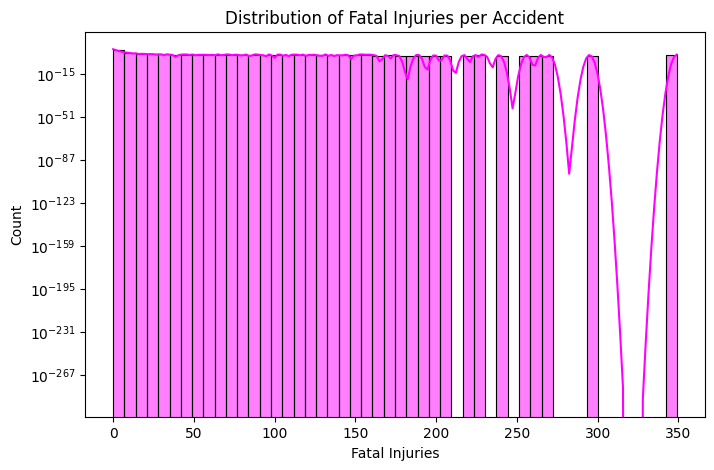

In [36]:
# Distribution of Fatal Injuries
plt.figure(figsize=(8, 5))
sns.histplot(df["Total.Fatal.Injuries"], bins=50, kde=True, color="magenta")
plt.title("Distribution of Fatal Injuries per Accident")
plt.xlabel("Fatal Injuries")
plt.ylabel("Count")
plt.yscale("log")
plt.show()

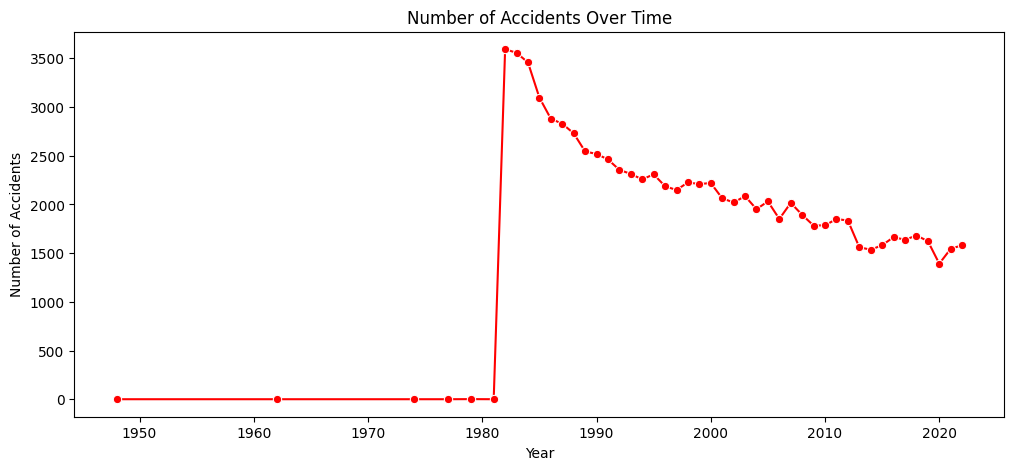

In [48]:
#Accidents trends over time
accidents_per_year = df["Event.Date"].dt.year.value_counts().sort_index()
plt.figure(figsize=(12, 5))
sns.lineplot(x=accidents_per_year.index, y=accidents_per_year.values, marker="o", color="Red")
plt.title("Number of Accidents Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

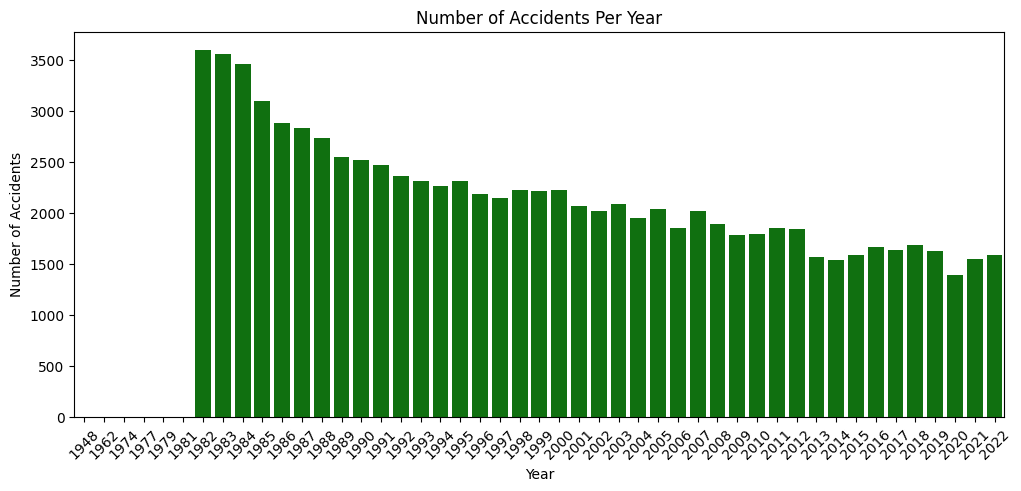

In [49]:
# Bar Graph of accidents trends per year
plt.figure(figsize=(12, 5))
sns.barplot(x=accidents_per_year.index, y=accidents_per_year.values, color="green")
plt.title("Number of Accidents Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

In [52]:
df.columns


Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

C:\Users\USER\AppData\Local\Temp\ipykernel_14628\709406067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Aircraft.damage"], order=df["Aircraft.damage"].value_counts().index, palette="coolwarm")


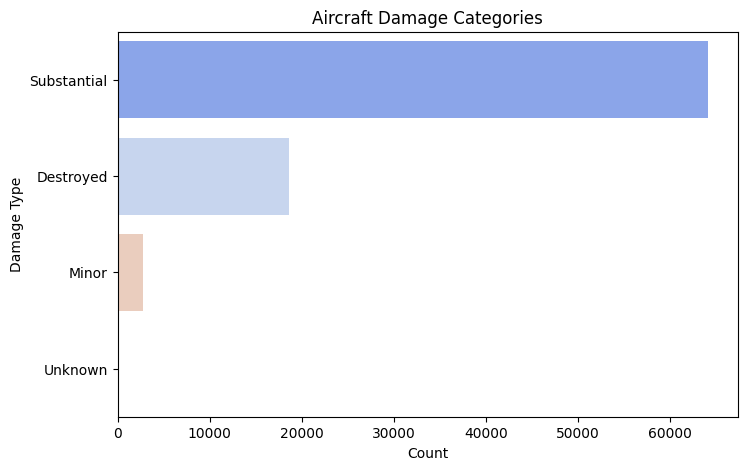

In [53]:
#Aircraft Damage Count
plt.figure(figsize=(8, 5))
sns.countplot(y=df["Aircraft.damage"], order=df["Aircraft.damage"].value_counts().index, palette="coolwarm")
plt.title("Aircraft Damage Categories")
plt.xlabel("Count")
plt.ylabel("Damage Type")
plt.show()

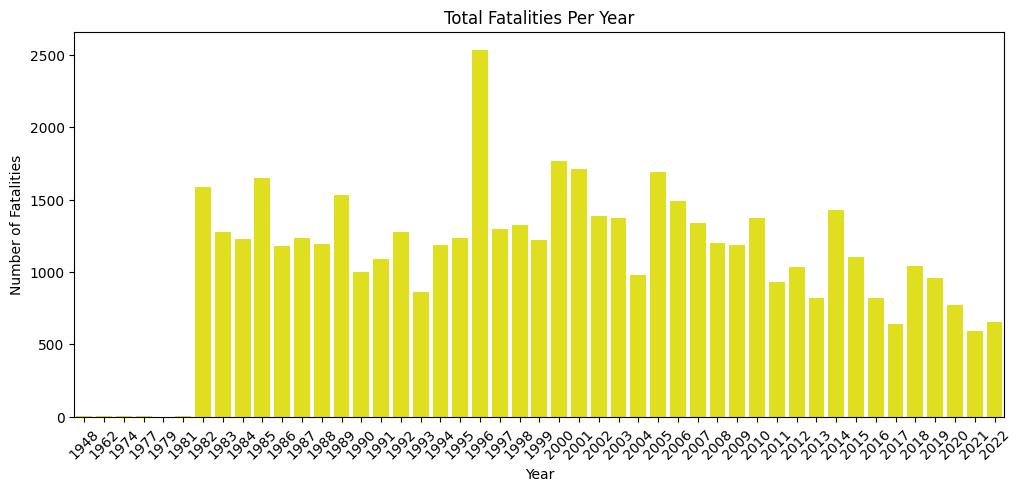

In [54]:
#Bar Graph of fatalities per year
fatalities_per_year = df.groupby(df["Event.Date"].dt.year)["Total.Fatal.Injuries"].sum()
plt.figure(figsize=(12, 5))
sns.barplot(x=fatalities_per_year.index, y=fatalities_per_year.values, color="yellow")
plt.title("Total Fatalities Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")
plt.xticks(rotation=45)
plt.show()

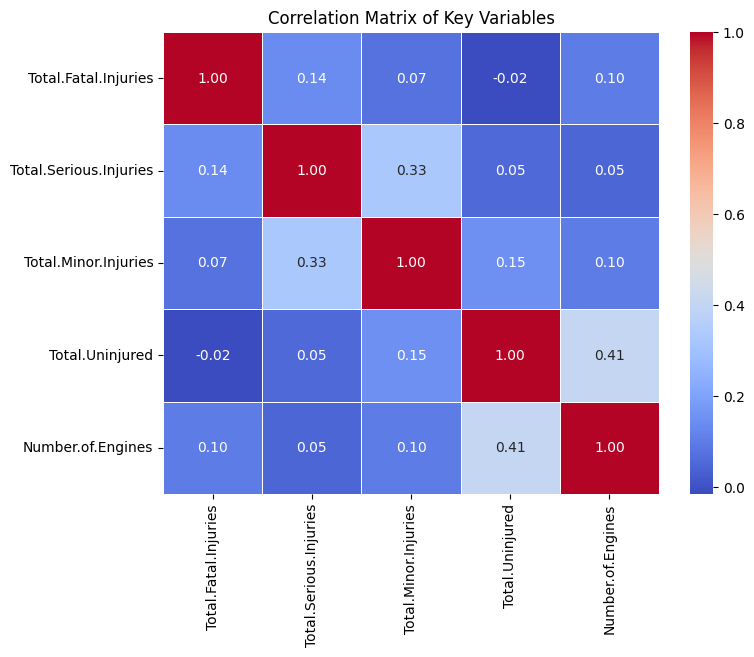

In [55]:
#Correlation Analysis
correlation_matrix = df[["Total.Fatal.Injuries", "Total.Serious.Injuries", "Total.Minor.Injuries", "Total.Uninjured", "Number.of.Engines"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Variables")
plt.show()
